In [11]:
from libero.libero.envs import OffScreenRenderEnv
from IPython.display import display
from PIL import Image
import os
import random
import time
from typing import Any, Dict, List, Optional, Union
import numpy as np
import torch
import json

bddl_file_name = '/home/joe/LIBERO/libero/libero/bddl_files/libero_object/pick_up_the_chocolate_pudding_and_place_it_in_the_basket.bddl'
env_args = {
    "bddl_file_name": bddl_file_name,
    "camera_heights": 256,
    "camera_widths": 256,
    "initialization_noise": "default",
}
states = []
images = []
for i in range(20):
    env = OffScreenRenderEnv(**env_args)
    obs = env.reset()
    state = env.get_sim_state()
    # Fix Basket
    state[17:19] = [0, 0.26]
    # Fix BBQ Sauce
    state[31:33] = [-0.15, 0.06]

    # 3: Ketchup next to chocolate pudding
    state[38:40] = [-0.16, -0.17]
    state[45:47] = [-0.16, -0.33]
    # 4: Move target object by -0.01 in x
    #state[10:12] = [-0.13, -0.24]
    # 5: Swap
    # tmp = state[10:12].copy()
    # state[10:12] = state[31:33]
    # state[31:33] = tmp
    # 6: Move object out of scene
    # state[31:33] = [5, 5]
    # # 7: 2 objects out
    # state[38:40] = [8, 8]
    states.append(state)
    obs = env.set_init_state(state)
    img = Image.fromarray(obs["agentview_image"][::-1])
    images.append(img)
env.close()

In [ ]:
from libero.libero.envs import OffScreenRenderEnv
from IPython.display import display
from PIL import Image
import os
import random
import time
from typing import Any, Dict, List, Optional, Union
import numpy as np
import torch
import json

bddl_file_name = '/home/joe/LIBERO/notebooks/bddl_files/pick_up_the_chocolate_pudding_and_place_it_in_the_basket_8.bddl'
env_args = {
    "bddl_file_name": bddl_file_name,
    "camera_heights": 256,
    "camera_widths": 256,
    "initialization_noise": "default",
}
states = []
images = []
for i in range(20):
    env = OffScreenRenderEnv(**env_args)
    obs = env.reset()
    state = env.get_sim_state()
    # Fix Basket
    state[17:19] = [0, 0.26]
    # Fix BBQ Sauce
    state[31:33] = [-0.15, 0.06]
    states.append(state)
    obs = env.set_init_state(state)
    img = Image.fromarray(obs["agentview_image"][::-1])
    images.append(img)
env.close()

In [21]:
from libero.libero.envs import OffScreenRenderEnv
from IPython.display import display
from PIL import Image
import os
import random
import time
from typing import Any, Dict, List, Optional, Union
import numpy as np
import torch
import json

bddl_file_name = '/home/joe/LIBERO/notebooks/bddl_files/pick_up_the_chocolate_pudding_and_place_it_in_the_basket_10_17.bddl'
env_args = {
    "bddl_file_name": bddl_file_name,
    "camera_heights": 256,
    "camera_widths": 256,
    "initialization_noise": "default",
}
states = []
images = []
for i in range(20):
    env = OffScreenRenderEnv(**env_args)
    obs = env.reset()
    state = env.get_sim_state()
    # Fix Choc Pudding
    state[10:12] = [-0.12, -0.24]
    # Fix Basket
    state[17:19] = [0, 0.26]
    # Fix orange juice
    state[24:26] = [0.05, -0.1]
    # Fix BBQ Sauce
    state[31:33] = [-0.15, 0.06]
    # Fix Ketchup
    state[38:40] = [0.1, -0.2]
    # Fix Salad Dressing
    state[45:47] = [0.15, 0.03]
    # Fix Alphabet Soup
    state[52:54] = [-0.2, -0.08]
    # # 2: Move bbq by -0.01 in x 
    # state[31:33] = [-0.16, 0.06]
    # 3: Ketchup next to chocolate pudding
    state[38:40] = [-0.185, -0.18]
    state[24:26] = [-0.185, -0.32]
    # 4: Move target object by -0.01 in x
    # state[10:12] = [-0.13, -0.24]
    # 5: Swap
    # tmp = state[10:12].copy()
    # state[10:12] = state[31:33]
    # state[31:33] = tmp
    # # 6: Move object out of scene
    # state[31:33] = [5, 5]
    # # # 7: 2 objects out
    # state[38:40] = [8, 8]
    states.append(state)
    obs = env.set_init_state(state)
    img = Image.fromarray(obs["agentview_image"][::-1])
    images.append(img)
env.close()

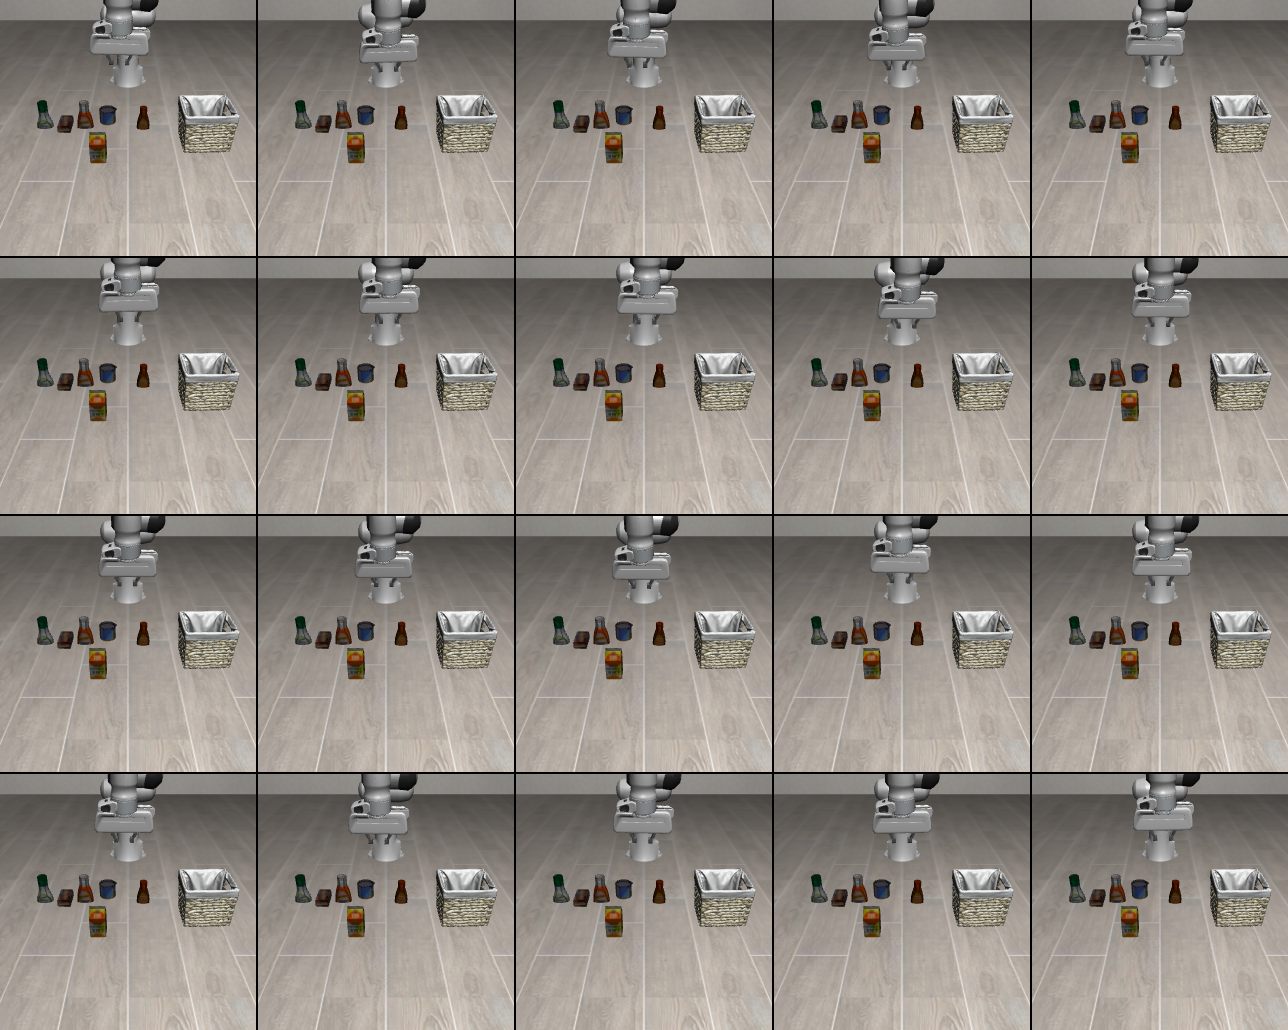

In [12]:
def make_image_grid(images, nrow=8, padding=2, pad_value=0):
    """Creates a grid from a list of PIL Images."""
    if not images:
        raise ValueError("Image list is empty.")

    w, h = images[0].size
    ncols = nrow
    nrows = (len(images) + ncols - 1) // ncols

    grid_w = ncols * w + padding * (ncols - 1)
    grid_h = nrows * h + padding * (nrows - 1)

    # Background color for padding
    background = (pad_value, pad_value, pad_value)
    grid_img = Image.new("RGB", (grid_w, grid_h), color=background)

    for idx, img in enumerate(images):
        row = idx // ncols
        col = idx % ncols
        x = col * (w + padding)
        y = row * (h + padding)
        grid_img.paste(img, (x, y))

    return grid_img

grid_image = make_image_grid(images, nrow=5, padding=2, pad_value=0)
display(grid_image)

In [13]:
import pickle   # Import the pickle module
import pathlib  # Import the pathlib module

file_path_str = 'init_states/initial_states18.pkl'

# Create a Path object
file_path = pathlib.Path(file_path_str)

try:
  if not file_path.exists():
    file_path.parent.mkdir(parents=True, exist_ok=True)
    with file_path.open('wb') as pkl_file:
      pickle.dump(states, pkl_file)
  else:
    print(f"File {file_path} already exists. Skipping creation.")

except Exception as e:
  print(f"An error occurred: {e}")